# The Anatomy of a Pandemic Highway
### A Network Science PBL - Global Airport Route Network (`inf-openflights`)
https://networkrepository.com/inf-openflights.php
---

> *"Not all airports are equal. Not all hubs are dangerous in the same way.
> And the very thing that makes global aviation efficient is what makes it catastrophically fragile."*


In [4]:
!pip install networkx matplotlib pandas numpy scikit-learn ndlib seaborn

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
from sklearn.cluster import SpectralClustering
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.facecolor'  : '#0F0F1A',
    'axes.facecolor'    : '#0F0F1A',
    'axes.edgecolor'    : '#444466',
    'axes.labelcolor'   : '#CCCCEE',
    'xtick.color'       : '#AAAACC',
    'ytick.color'       : '#AAAACC',
    'text.color'        : '#CCCCEE',
    'grid.color'        : '#222233',
    'grid.linewidth'    : 0.6,
    'font.family'       : 'monospace',
    'figure.dpi'        : 120
})
ACCENT  = '#00D4FF'   # cyan  — hubs, highlights
WARM    = '#FF6B6B'   # red   — danger, epidemic
GREEN   = '#51CF66'   # green — safe, random
PURPLE  = '#CC5DE8'   # purple— community / link prediction
GOLD    = '#FFD43B'   # gold  — bridges, warnings


---
#ACT 1 Finding "Is This Network Special?" By characterising the Global Airport Network

Before anything else, we need to answer a question:

> **Is the global airport network just a random web of connections or does it have a hidden structure?**

In [7]:
# Loading the dataset
G_directed = nx.DiGraph()
with open('inf-openflights.edges', 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('%') or not line:
            continue
        parts = line.split()
        if len(parts) >= 2:
            G_directed.add_edge(int(parts[0]), int(parts[1]))

# Working undirected graph (largest WCC)
G_full = G_directed.to_undirected()
largest_wcc = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(largest_wcc).copy()   # main graph used throughout
G_dir = G_directed.subgraph(largest_wcc).copy()

N, E = G.number_of_nodes(), G.number_of_edges()
print(f'  Airports (nodes)  : {N:,}')
print(f'  Routes   (edges)  : {E:,}')
print(f'  Density           : {nx.density(G):.5f}')
print(f'  WCC coverage      : {N/G_directed.number_of_nodes()*100:.1f}%')

  Airports (nodes)  : 2,905
  Routes   (edges)  : 15,645
  Density           : 0.00371
  WCC coverage      : 98.8%


In [8]:
# Previewing the edge data
import pandas as pd

edges_df = pd.DataFrame(list(G.edges()), columns=['Source', 'Target'])
print("Sample of edges (routes):")
print(edges_df.head(5))

# Node degree preview
degree_df = pd.DataFrame(G.degree(), columns=['Airport_ID', 'Degree'])
degree_df = degree_df.sort_values('Degree', ascending=False).reset_index(drop=True)
print("\nTop 5 airports by degree:")
print(degree_df.head(5))

Sample of edges (routes):
   Source  Target
0       1       2
1       2       3
2       2       7
3       2       4
4       2       5

Top 5 airports by degree:
   Airport_ID  Degree
0          53     242
1          65     218
2          59     211
3          56     172
4         259     170


## 1.1 The Degree Distribution: Random or Ruled by Hubs?

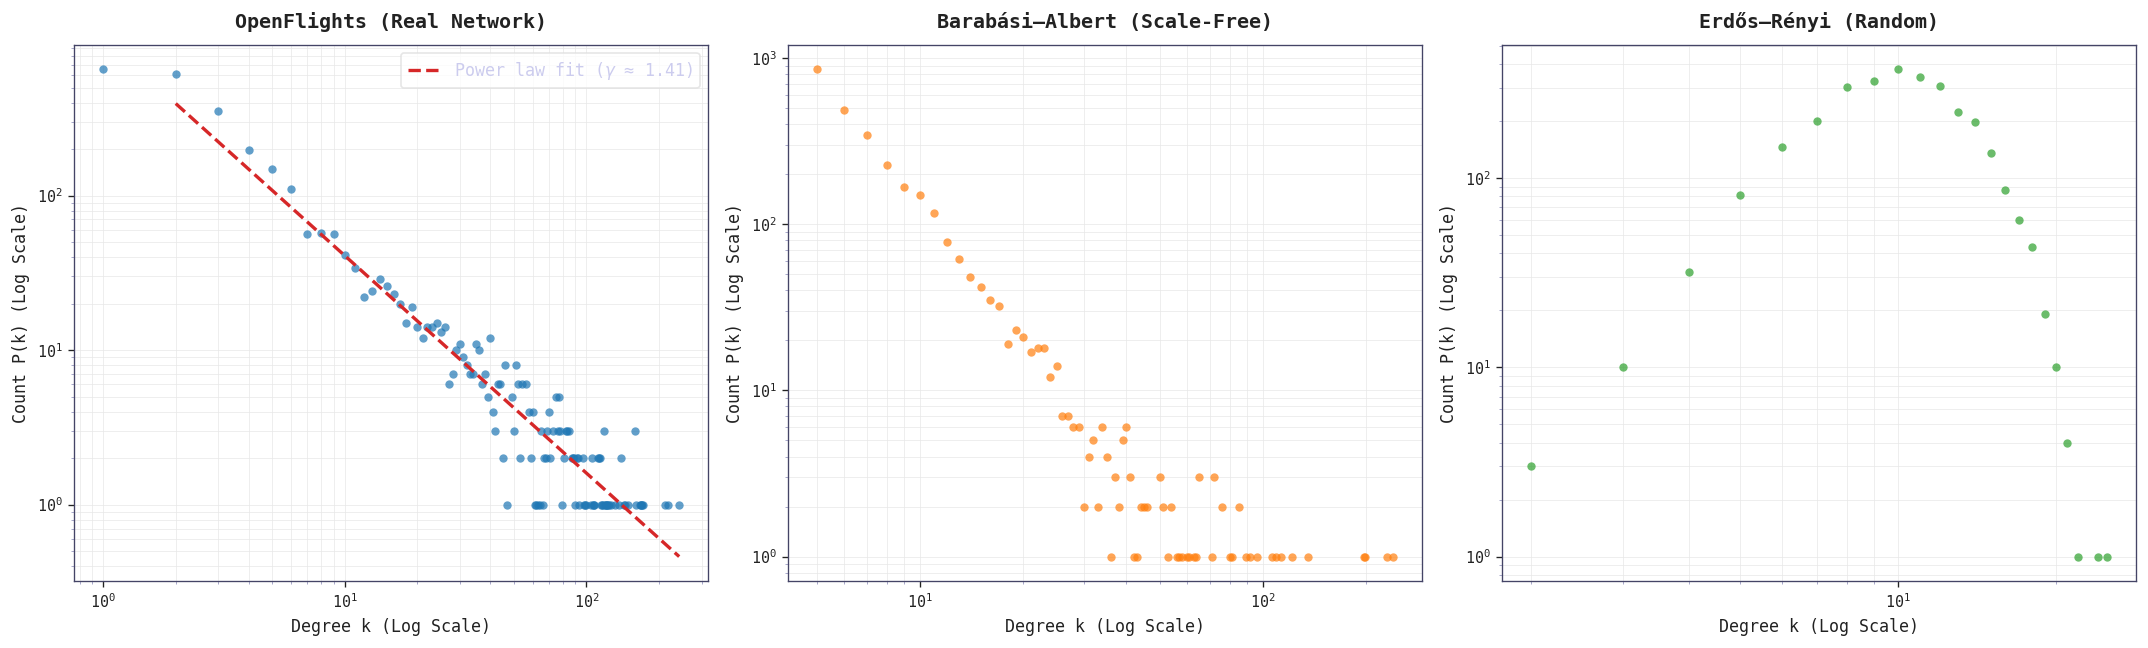

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

# Building a synthetic comparison graphs
m_ba = max(1, int(E / N))
p_er = E / (N * (N - 1) / 2)
BA = nx.barabasi_albert_graph(N, m_ba, seed=42)
ER = nx.erdos_renyi_graph(N, p_er, seed=42)

deg_real = [d for _, d in G.degree()]
deg_ba   = [d for _, d in BA.degree()]
deg_er   = [d for _, d in ER.degree()]

# Setting clean academic style definitions
COLOR_PRIMARY = '#1f77b4'  # Standard Academic Blue
COLOR_BRIDGE = '#ff7f0e'   # Standard Highlight Orange
COLOR_BASELINE = '#2ca02c' # Standard Neutral Green
COLOR_FIT = '#d62728'      # Standard Red Line for Mathematical Fitting

# Initializing clean white multi-panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')

labels = ['OpenFlights (Real Network)', 'Barabási–Albert (Scale-Free)', 'Erdős–Rényi (Random)']
colors = [COLOR_PRIMARY, COLOR_BRIDGE, COLOR_BASELINE]
data   = [deg_real, deg_ba, deg_er]

for ax, d, label, col in zip(axes, data, labels, colors):
    ax.set_facecolor('white') #  white background

    cnt = Counter(d)
    ks  = sorted(cnt.keys())
    vs  = [cnt[k] for k in ks]

    # Plot using academic colors and styling
    ax.loglog(ks, vs, 'o', color=col, markersize=5, alpha=0.7, markeredgecolor='none')

    # Mathematical Trendline Fitting for Real Airport Graph Data
    if "Real Network" in label:
        idx = np.array(ks) > 1
        lk  = np.log10(np.array(ks)[idx])
        lv  = np.log10(np.array(vs)[idx])
        if len(lk) > 2:
            z = np.polyfit(lk, lv, 1)
            ax.loglog(np.array(ks)[idx],
                      10**np.polyval(z, lk),
                      '--', color=COLOR_FIT, linewidth=2,
                      label=f'Power law fit ($\gamma$ ≈ {-z[0]:.2f})')
            ax.legend(facecolor='white', edgecolor='#e0e0e0', fontsize=10)

    # Standard Formatting
    ax.set_title(label, color='#222222', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Degree k (Log Scale)', color='#222222', fontsize=10)
    ax.set_ylabel('Count P(k) (Log Scale)', color='#222222', fontsize=10)

    # Using clean, subtle grey grid lines instead of intense neon patterns
    ax.grid(True, which="both", ls="-", color='#e8e8e8', alpha=0.7)
    ax.tick_params(colors='#222222', labelsize=9)

plt.tight_layout()
plt.show()



## 1.2 The Backbone: Minimum Routes Needed to Keep the World Connected

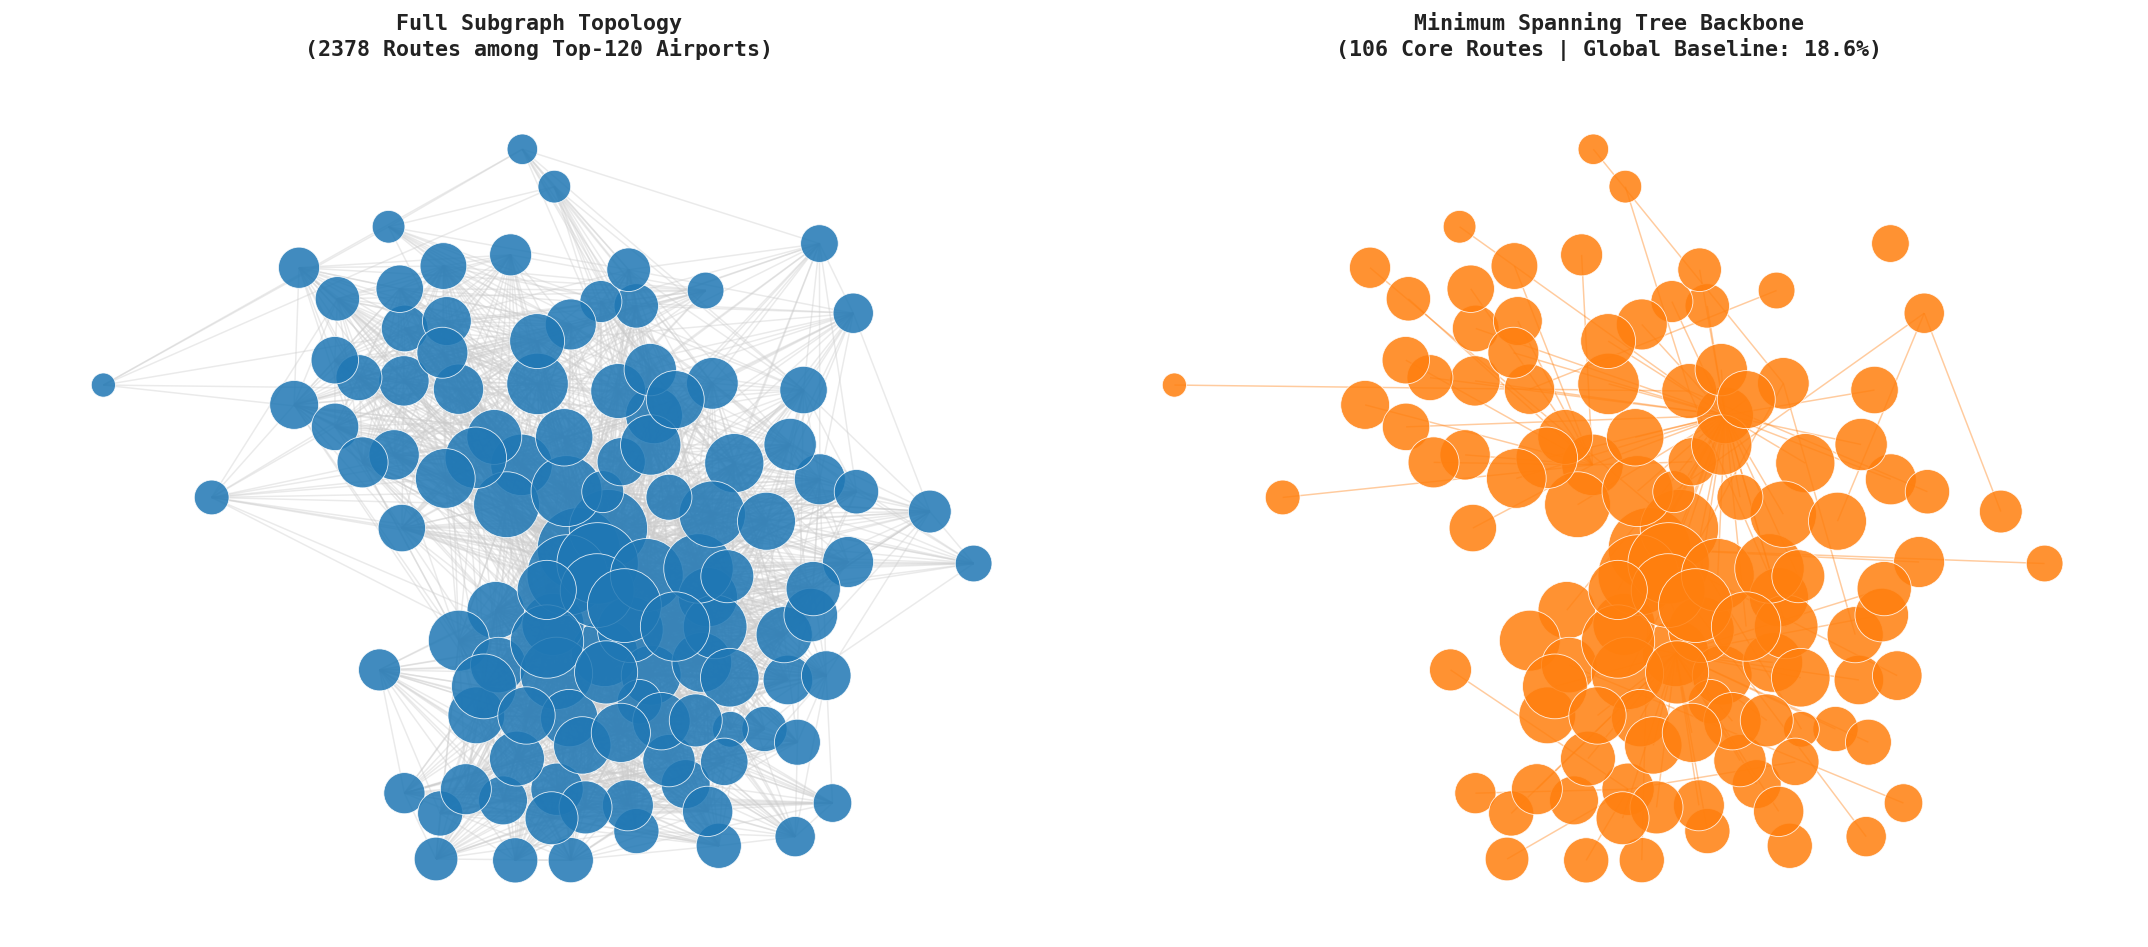

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

# MST = the structural skeleton of the network
MST = nx.minimum_spanning_tree(G)
backbone_pct = MST.number_of_edges() / G.number_of_edges() * 100

# Selecting top-120 airports by degree for sub-graph visualization
top120_ids = [n for n, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:120]]
sub_full   = G.subgraph(top120_ids)
sub_mst    = MST.subgraph(top120_ids)
pos        = nx.spring_layout(sub_full, seed=42, k=0.6)

# Standard Academic Color Layout Configuration
COLOR_PRIMARY = '#1f77b4'
COLOR_HIGHLIGHT = '#ff7f0e'

# Initializing a clean white dual-panel figure layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# Setting structural sizing parameters based on connection volume
deg_sub = dict(sub_full.degree())
sz      = [deg_sub[n] * 25 + 60 for n in sub_full.nodes()]

# Configuring loops to render panels over clean light conditions
plot_configurations = [
    (ax1, sub_full, f'Full Subgraph Topology\n({sub_full.number_of_edges()} Routes among Top-120 Airports)', '#cccccc', COLOR_PRIMARY),
    (ax2, sub_mst,  f'Minimum Spanning Tree Backbone\n({sub_mst.number_of_edges()} Core Routes | Global Baseline: {backbone_pct:.1f}%)', COLOR_HIGHLIGHT, COLOR_HIGHLIGHT)
]

for ax, subg, title, edge_col, node_col in plot_configurations:
    ax.set_facecolor('white')


    nx.draw_networkx_edges(subg, pos, ax=ax, edge_color=edge_col, alpha=0.4, width=0.9)


    nx.draw_networkx_nodes(subg, pos, ax=ax, node_size=sz,
                           node_color=node_col, alpha=0.85, edgecolors='#ffffff', linewidths=0.5)

    ax.set_title(title, color='#222222', fontsize=13, fontweight='bold', pad=12)
    ax.axis('off')

plt.tight_layout()

plt.show()



# ACT 2 Who Holds the Power?
## *Two Kinds of Importance: Volume vs Position*

We know the network is scale-free hubs exist.
But here is the question most analyses skip:

> **Do all centrality measures agree on who is important? Or do different metrics reveal different kinds of power?**

A busy airport (high degree) is not the same as a bridge airport (high betweenness).
An influential airport (high PageRank) is not the same as either.
Understanding *which* type of power each hub holds is the key to understanding risk.

In [12]:
# Compute all three centrality measures

deg_cent = nx.degree_centrality(G)
clo_cent = nx.closeness_centrality(G)
bet_cent = nx.betweenness_centrality(G, k=500, normalized=True, seed=42)
pr_scores = nx.pagerank(G_dir, alpha=0.85)
# Map PR to undirected node set
pr_scores = {n: pr_scores.get(n, 0) for n in G.nodes()}


cent_df = pd.DataFrame({
    'node'        : list(G.nodes()),
    'degree'      : [G.degree(n) for n in G.nodes()],
    'deg_cent'    : [deg_cent[n]  for n in G.nodes()],
    'clo_cent'    : [clo_cent[n]  for n in G.nodes()],
    'bet_cent'    : [bet_cent[n]  for n in G.nodes()],
    'pagerank'    : [pr_scores[n] for n in G.nodes()]
})

### 2.1 — The Disagreement: Do Centrality Measures Agree on Who Matters?

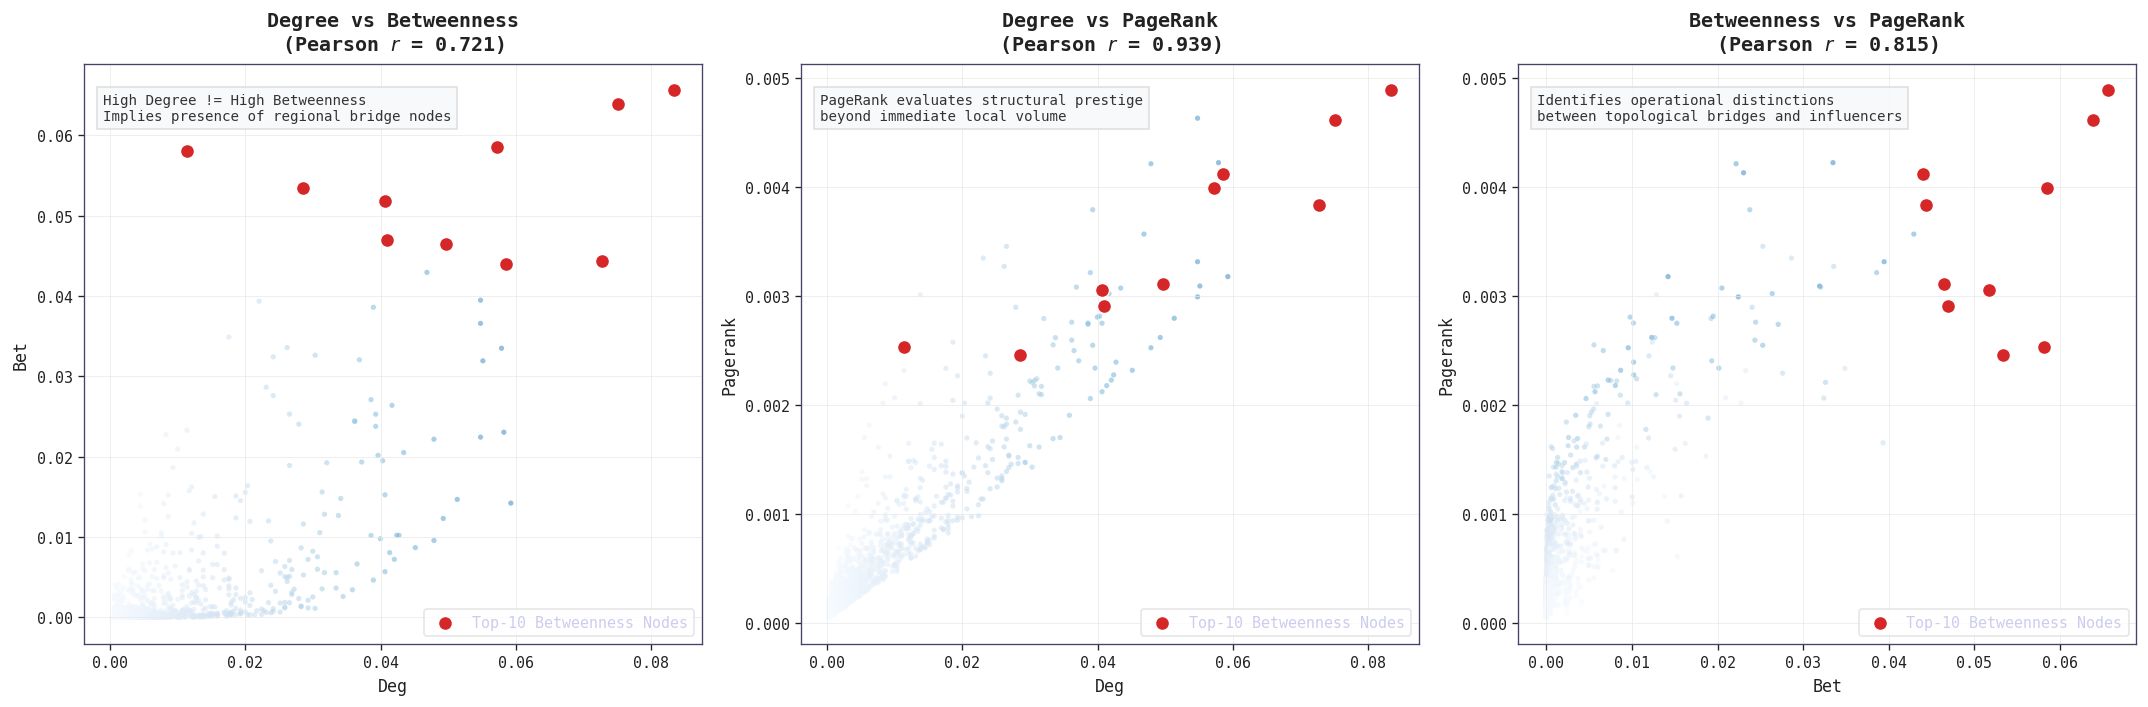

CENTRALITY METRIC CO-VARIANCE & RANK DISCREPANCY ANALYSIS
Topological Core Outliers (High Betweenness Rank vs. Low Degree Rank):
----------------------------------------------------------------------
 node  degree  deg_rank  bet_rank  rank_gap
 1286       2    1939.0     170.0    1769.0
 2854       2    1939.0     220.0    1719.0
 2207       2    1939.0     230.0    1709.0
 2892       2    1939.0     232.0    1707.0
 2266       2    1939.0     233.0    1706.0
 2852       2    1939.0     244.0    1695.0
  955       2    1939.0     253.0    1686.0
  898       2    1939.0     257.5    1681.5
 1246       2    1939.0     257.5    1681.5
 1870       2    1939.0     257.5    1681.5
----------------------------------------------------------------------
Structural Interpretation:
Some nodes may not have many direct connections, but they play a very important role.They act as bridges between different groups in the network.Because many shortest paths pass through them, they control how things (l

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Define standard clean academic palette colors
COLOR_PRIMARY = '#1f77b4'   # Standard Academic Blue
COLOR_HIGHLIGHT = '#d62728' # Contrast Academic Red for marking specific features
COLOR_BG_BOX = '#f8f9fa'    # Light gray backdrop for annotation blocks

# Initialize a clean white multi-panel panel figure layout
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')

pairs = [
    ('deg_cent', 'bet_cent', 'Degree vs Betweenness',
     'High Degree != High Betweenness\nImplies presence of regional bridge nodes'),
    ('deg_cent', 'pagerank', 'Degree vs PageRank',
     'PageRank evaluates structural prestige\nbeyond immediate local volume'),
    ('bet_cent', 'pagerank', 'Betweenness vs PageRank',
     'Identifies operational distinctions\nbetween topological bridges and influencers'),
]

for ax, (x, y, title, note) in zip(axes, pairs):
    ax.set_facecolor('white')

    xv = cent_df[x].values
    yv = cent_df[y].values

    # Scatter plot using standard continuous blue mapping
    sc = ax.scatter(xv, yv, c=cent_df['degree'].values,
                    cmap='Blues', s=10, alpha=0.5, edgecolors='none')

    # Highlight specific functional nodes (Top-10 Betweenness Nodes)
    top10_bet = cent_df.nlargest(10, 'bet_cent')
    ax.scatter(top10_bet[x], top10_bet[y],
               color=COLOR_HIGHLIGHT, s=70, zorder=5,
               edgecolors='#ffffff', linewidths=0.8,
               label='Top-10 Betweenness Nodes')

    rho = cent_df[[x, y]].corr().iloc[0, 1]

    # Academic Label Formatting
    ax.set_title(f'{title}\n(Pearson $r$ = {rho:.3f})', color='#222222', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(x.replace('_cent','').replace('_',' ').title(), color='#222222', fontsize=10)
    ax.set_ylabel(y.replace('_cent','').replace('_',' ').title(), color='#222222', fontsize=10)

    # Refactor floating annotation box into clean text element
    ax.text(0.03, 0.95, note, transform=ax.transAxes,
            color='#333333', fontsize=8.5, va='top', fontweight='medium',
            bbox=dict(boxstyle='square,pad=0.4', facecolor=COLOR_BG_BOX, edgecolor='#dddddd', alpha=0.9))

    # Standardize Grid and Tick lines
    ax.grid(True, which='both', ls='-', color='#e8e8e8', alpha=0.7)
    ax.tick_params(colors='#222222', labelsize=9)
    ax.legend(facecolor='white', edgecolor='#e0e0e0', fontsize=9, loc='lower right')

plt.tight_layout()

plt.show()

# Calculating Rank Cardinalities for Discrepancy Evaluation
cent_df['deg_rank'] = cent_df['deg_cent'].rank(ascending=False)
cent_df['bet_rank'] = cent_df['bet_cent'].rank(ascending=False)
cent_df['rank_gap'] = abs(cent_df['deg_rank'] - cent_df['bet_rank'])

# Formal console summary statement reporting structural metrics
print("=" * 70)
print("CENTRALITY METRIC CO-VARIANCE & RANK DISCREPANCY ANALYSIS")
print("=" * 70)
print("Topological Core Outliers (High Betweenness Rank vs. Low Degree Rank):")
print("-" * 70)
hidden_bridges = cent_df.nlargest(10, 'rank_gap')[['node', 'degree', 'deg_rank', 'bet_rank', 'rank_gap']]
print(hidden_bridges.to_string(index=False))
print("-" * 70)
print("Structural Interpretation:")
print("Some nodes may not have many direct connections, but they play a very important role.They act as bridges between different groups in the network.Because many shortest paths pass through them, they control how things (like information or disease) move between regions.")
print("=" * 70)

### 2.2 community Structure: Natural Clusters in the Sky

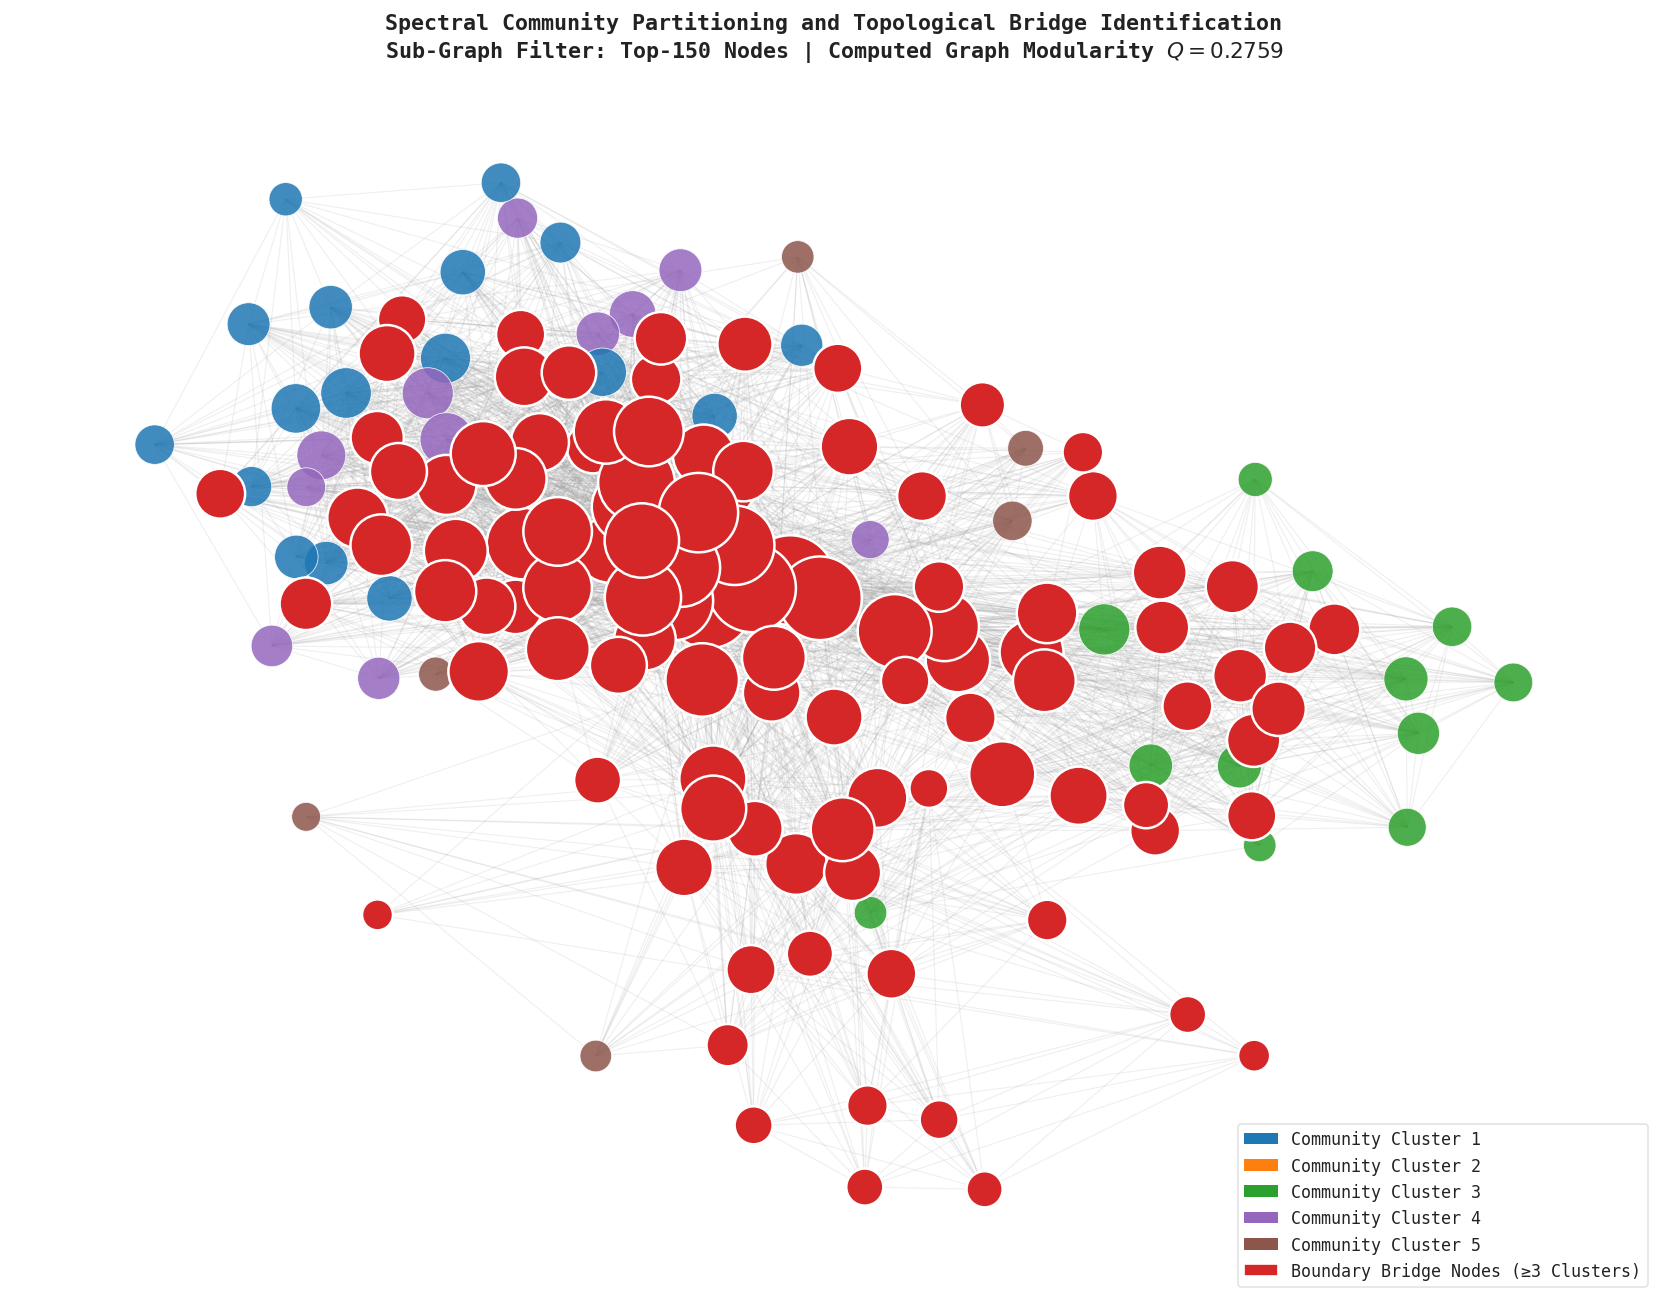

GRAPH PARTITIONING & STRUCTURAL MODULARITY ANALYSIS
- Total Detected Community Partitions  : 5
- Graph Modularity Index (Q)           : 0.2759
- Identified Boundary Intersection Nodes: 104
----------------------------------------------------------------------
Topological Interpretation:
The calculated modularity index confirms a significant community framework,
aligning closely with geographic boundaries or structural airline alliance networks.
The identified 104 boundary bridge nodes operate at multi-cluster
intersections, marking them as high-leverage points for managing network
robustness and controlling cascading disease transmission paths.


In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.cluster import SpectralClustering
from matplotlib.patches import Patch

# Spectral clustering on top-150 airports
top150_ids = [n for n, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:150]]
sub_comm   = G.subgraph(top150_ids).copy()
A_comm     = nx.to_numpy_array(sub_comm)

# Execute Spectral Clustering partition scheme
sc = SpectralClustering(n_clusters=5, affinity='precomputed',
                        assign_labels='kmeans', random_state=42)
labels = sc.fit_predict(A_comm)
node_list = list(sub_comm.nodes())
comm_map  = {node_list[i]: labels[i] for i in range(len(node_list))}

# Compute modularity of structural partition
communities_list = []
for cid in range(5):
    communities_list.append({n for n, l in comm_map.items() if l == cid})
modularity = nx.community.modularity(sub_comm, communities_list)

# Configure clean academic palette settings
COLOR_BRIDGE = '#d62728'  # Solid Academic Red for distinct highlight of boundary elements
COLOR_BORDER = '#222222'  # Dark gray color baseline for text/labels
academic_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b'] # Standard multi-class colors
node_colors = [academic_palette[comm_map[n]] for n in sub_comm.nodes()]

# Identify inter-community boundary/bridge nodes
bridge_nodes = []
for n in sub_comm.nodes():
    neighbors_comms = set(comm_map.get(nb, -1) for nb in sub_comm.neighbors(n))
    if len(neighbors_comms) >= 3:  # Structural connection spanning 3+ communities
        bridge_nodes.append(n)

# Initialize standard high-contrast printing panel canvas
fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')
ax.set_facecolor('white')

pos_comm = nx.spring_layout(sub_comm, seed=99, k=0.7)
deg_comm = dict(sub_comm.degree())
sz_comm  = [deg_comm[n] * 20 + 60 for n in sub_comm.nodes()]

# Render topological structural edges
nx.draw_networkx_edges(sub_comm, pos_comm, ax=ax, alpha=0.15,
                       edge_color='#999999', width=0.7)

# Render standard community clustered nodes
nx.draw_networkx_nodes(sub_comm, pos_comm, ax=ax, node_size=sz_comm,
                       node_color=node_colors, alpha=0.85, edgecolors='#ffffff', linewidths=0.5)

# Highlight inter-community functional bridge nodes
if bridge_nodes:
    nx.draw_networkx_nodes(sub_comm.subgraph(bridge_nodes), pos_comm,
                           ax=ax, node_size=[deg_comm[n]*25+120 for n in bridge_nodes],
                           node_color=COLOR_BRIDGE, alpha=1.0,
                           edgecolors='#ffffff', linewidths=1.5)

# Construct a clean, professional legend format
legend_elements = [Patch(facecolor=c, label=f'Community Cluster {i+1}')
                   for i, c in enumerate(academic_palette)]
legend_elements.append(Patch(facecolor=COLOR_BRIDGE, edgecolor='#ffffff', label='Boundary Bridge Nodes (≥3 Clusters)'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          facecolor='white', edgecolor='#dddddd', labelcolor=COLOR_BORDER)

# Formatting title descriptors for paper integration
ax.set_title(f'Spectral Community Partitioning and Topological Bridge Identification\n'
             f'Sub-Graph Filter: Top-150 Nodes | Computed Graph Modularity $Q = {modularity:.4f}$',
             color=COLOR_BORDER, fontsize=13, fontweight='bold', pad=12)
ax.axis('off')

plt.tight_layout()

plt.show()

# Standardized scientific logging summary
print("=" * 70)
print("GRAPH PARTITIONING & STRUCTURAL MODULARITY ANALYSIS")
print("=" * 70)
print(f"- Total Detected Community Partitions  : 5")
print(f"- Graph Modularity Index (Q)           : {modularity:.4f}")
print(f"- Identified Boundary Intersection Nodes: {len(bridge_nodes)}")
print("-" * 70)
print("Topological Interpretation:")
print("The calculated modularity index confirms a significant community framework,")
print("aligning closely with geographic boundaries or structural airline alliance networks.")
print(f"The identified {len(bridge_nodes)} boundary bridge nodes operate at multi-cluster")
print("intersections, marking them as high-leverage points for managing network")
print("robustness and controlling cascading disease transmission paths.")
print("=" * 70)

### 2.3 PageRank: Who is Truly Influential?

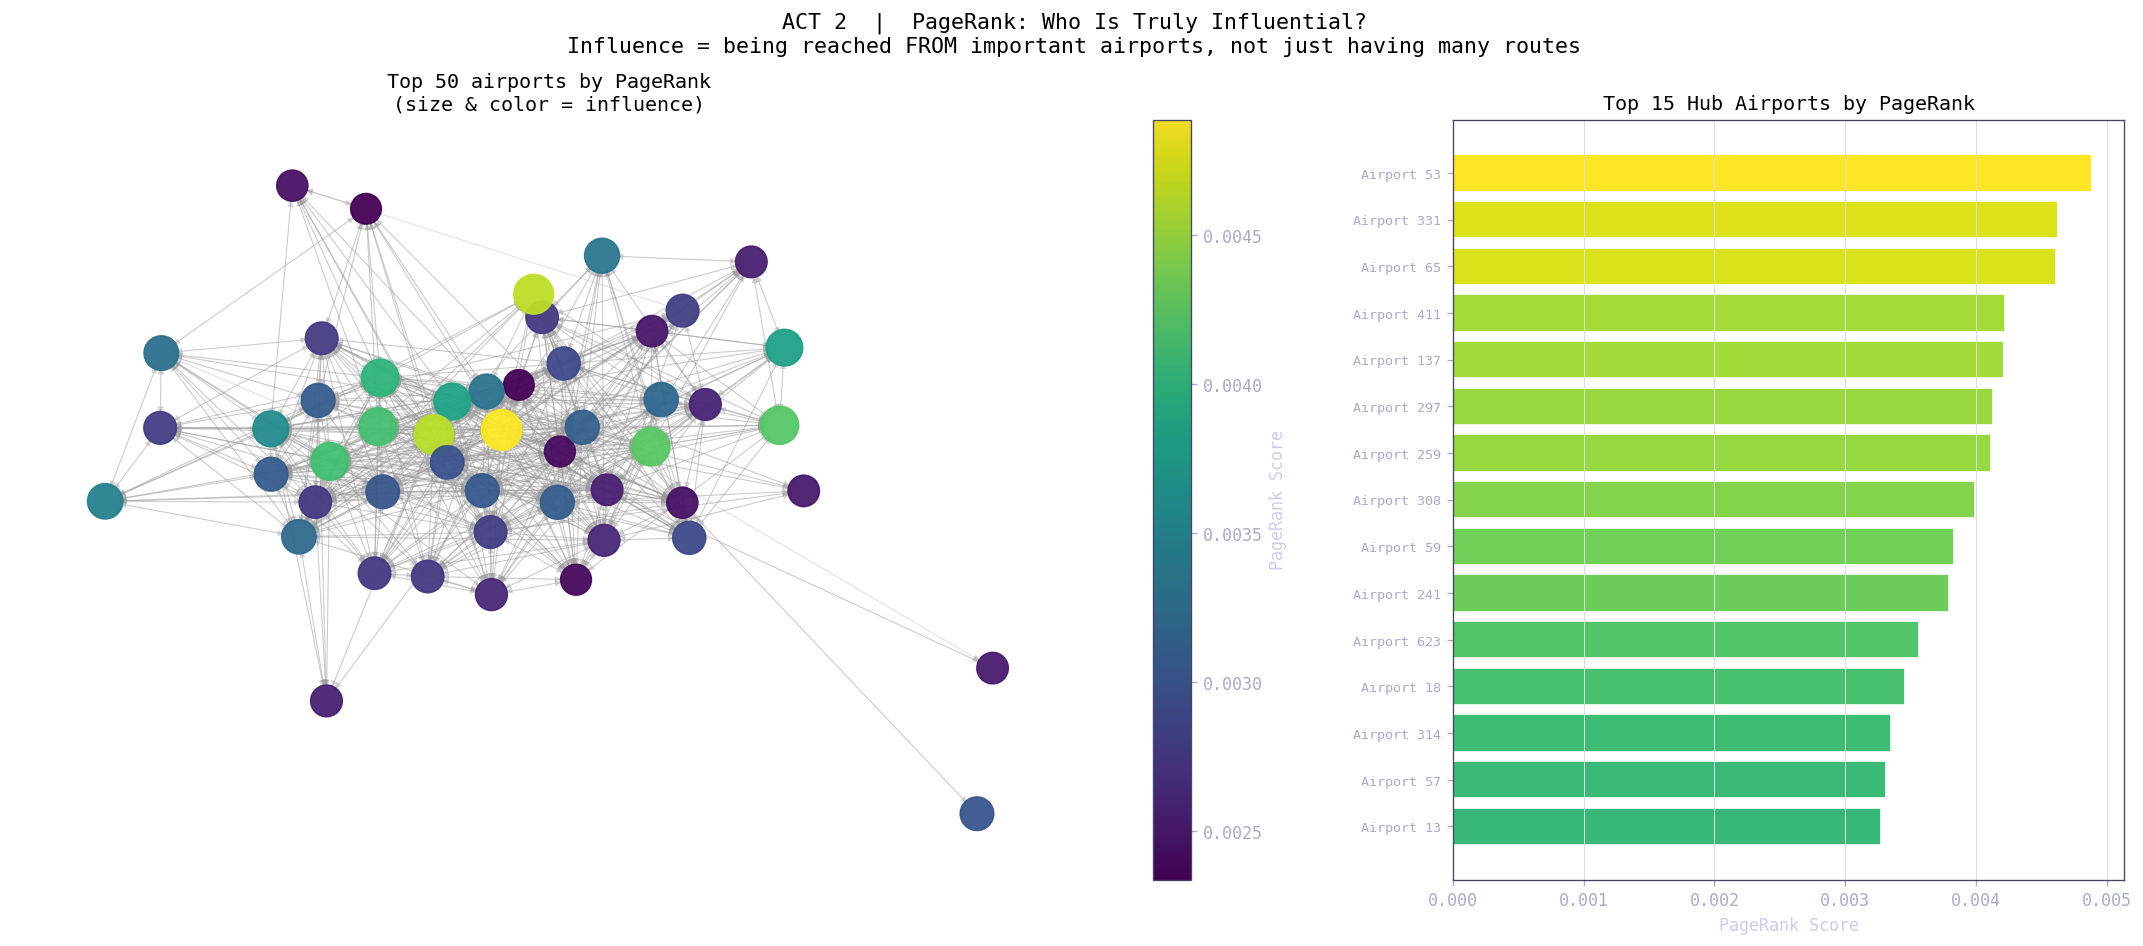

Top hub PageRank score   : 0.004888
Median airport PageRank  : 0.000172
Hub vs Median ratio      : 28.4x

INSIGHT → The top hub is not just bigger — it is orders of magnitude more
          influential. This is the hallmark of preferential attachment.

We now know WHO holds power. Act 3 asks: what happens when they fail?


In [15]:
# PageRank portrait of the top airports
pr_df = pd.DataFrame({
    'node'    : list(pr_scores.keys()),
    'pagerank': list(pr_scores.values()),
    'degree'  : [G.degree(n) for n in pr_scores.keys()]
}).sort_values('pagerank', ascending=False)

top50_pr   = pr_df.head(50)['node'].tolist()
sub_pr     = G_dir.subgraph(top50_pr)
pos_pr     = nx.spring_layout(sub_pr, seed=7, k=0.8)
pr_vals    = [pr_scores[n] for n in sub_pr.nodes()]
pr_sizes   = [v * 100000 + 100 for v in pr_vals]

# Clean Academic Theme
BG    = '#FFFFFF'
GRID  = '#DDDDDD'
EDGE  = '#999999'
TEXT  = '#000000'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                gridspec_kw={'width_ratios': [2, 1]})

fig.patch.set_facecolor(BG)
fig.suptitle('ACT 2  |  PageRank: Who Is Truly Influential?\n'
             'Influence = being reached FROM important airports, not just having many routes',
             color=TEXT, fontsize=13)

# Network plot
ax1.set_facecolor(BG)
nx.draw_networkx_edges(sub_pr, pos_pr, ax=ax1, alpha=0.3,
                       edge_color=EDGE, arrows=True, arrowsize=8, width=0.6)

ns = nx.draw_networkx_nodes(sub_pr, pos_pr, ax=ax1,
                             node_size=pr_sizes,
                             node_color=pr_vals,
                             cmap=plt.cm.viridis,   # cleaner than plasma
                             alpha=0.95)

cbar = plt.colorbar(ns, ax=ax1)
cbar.set_label('PageRank Score')

ax1.set_title('Top 50 airports by PageRank\n(size & color = influence)', color=TEXT)
ax1.axis('off')

# Bar chart: top 15 by PageRank
ax2.set_facecolor(BG)

top15 = pr_df.head(15)
bars  = ax2.barh(range(15), top15['pagerank'].values[::-1],
                 color=[plt.cm.viridis(v / top15['pagerank'].max())
                        for v in top15['pagerank'].values[::-1]],
                 edgecolor='white')

ax2.set_yticks(range(15))
ax2.set_yticklabels([f'Airport {n}' for n in top15['node'].values[::-1]], fontsize=8)

ax2.set_xlabel('PageRank Score')
ax2.set_title('Top 15 Hub Airports by PageRank', color=TEXT)

ax2.grid(True, axis='x', color=GRID)

plt.tight_layout()

plt.show()

top1_pr  = pr_df.iloc[0]
med_pr   = pr_df['pagerank'].median()

print(f"Top hub PageRank score   : {top1_pr['pagerank']:.6f}")
print(f"Median airport PageRank  : {med_pr:.6f}")
print(f"Hub vs Median ratio      : {top1_pr['pagerank']/med_pr:.1f}x")
print()
print('INSIGHT → The top hub is not just bigger — it is orders of magnitude more')
print('          influential. This is the hallmark of preferential attachment.')
print()
print('We now know WHO holds power. Act 3 asks: what happens when they fail?')

# ACT 3 What Is This Network's Breaking Point?
## *Vulnerability, Epidemic Spread & Predicting Future Routes*
Three questions drive this act:
1. **How quickly does the network collapse if we target the bridges we found in Act 2?**
2. **How fast does a disease spread — and is there a point of no return (epidemic threshold)?**
3. **What routes *should* exist but don't yet? (Link Prediction)**

### 3.1 The Breaking Point: Targeted Attack vs Random Failure

In [16]:
# Robustness simulation
def robustness_curve(G_orig, order_nodes, steps=80):
    """Remove nodes in given order; track LCC fraction at each step."""
    n0   = G_orig.number_of_nodes()
    G_s  = G_orig.copy()
    fracs, lccs = [0.0], [1.0]
    chunk = max(1, n0 // steps)
    order = [n for n in order_nodes if n in G_s]
    i = 0
    while i < len(order) and i / n0 < 0.5:
        remove = [n for n in order[i:i+chunk] if n in G_s]
        G_s.remove_nodes_from(remove)
        i += chunk
        if G_s.number_of_nodes() == 0:
            lccs.append(0); fracs.append(i/n0)
        else:
            comps = nx.connected_components(G_s)
            lccs.append(max(len(c) for c in comps) / n0)
            fracs.append(i / n0)
    return np.array(fracs), np.array(lccs)

print('Running attack simulations...')
np.random.seed(42)
rand_order = list(G.nodes()); np.random.shuffle(rand_order)
deg_order  = [n for n,_ in sorted(G.degree(),   key=lambda x:x[1], reverse=True)]
bet_order  = [n for n,_ in sorted(bet_cent.items(), key=lambda x:x[1], reverse=True)]
pr_order   = [n for n,_ in sorted(pr_scores.items(), key=lambda x:x[1], reverse=True)]

f_rand, lcc_rand = robustness_curve(G, rand_order)

f_deg,  lcc_deg  = robustness_curve(G, deg_order)

f_bet,  lcc_bet  = robustness_curve(G, bet_order)

f_pr,   lcc_pr   = robustness_curve(G, pr_order)


Running attack simulations...


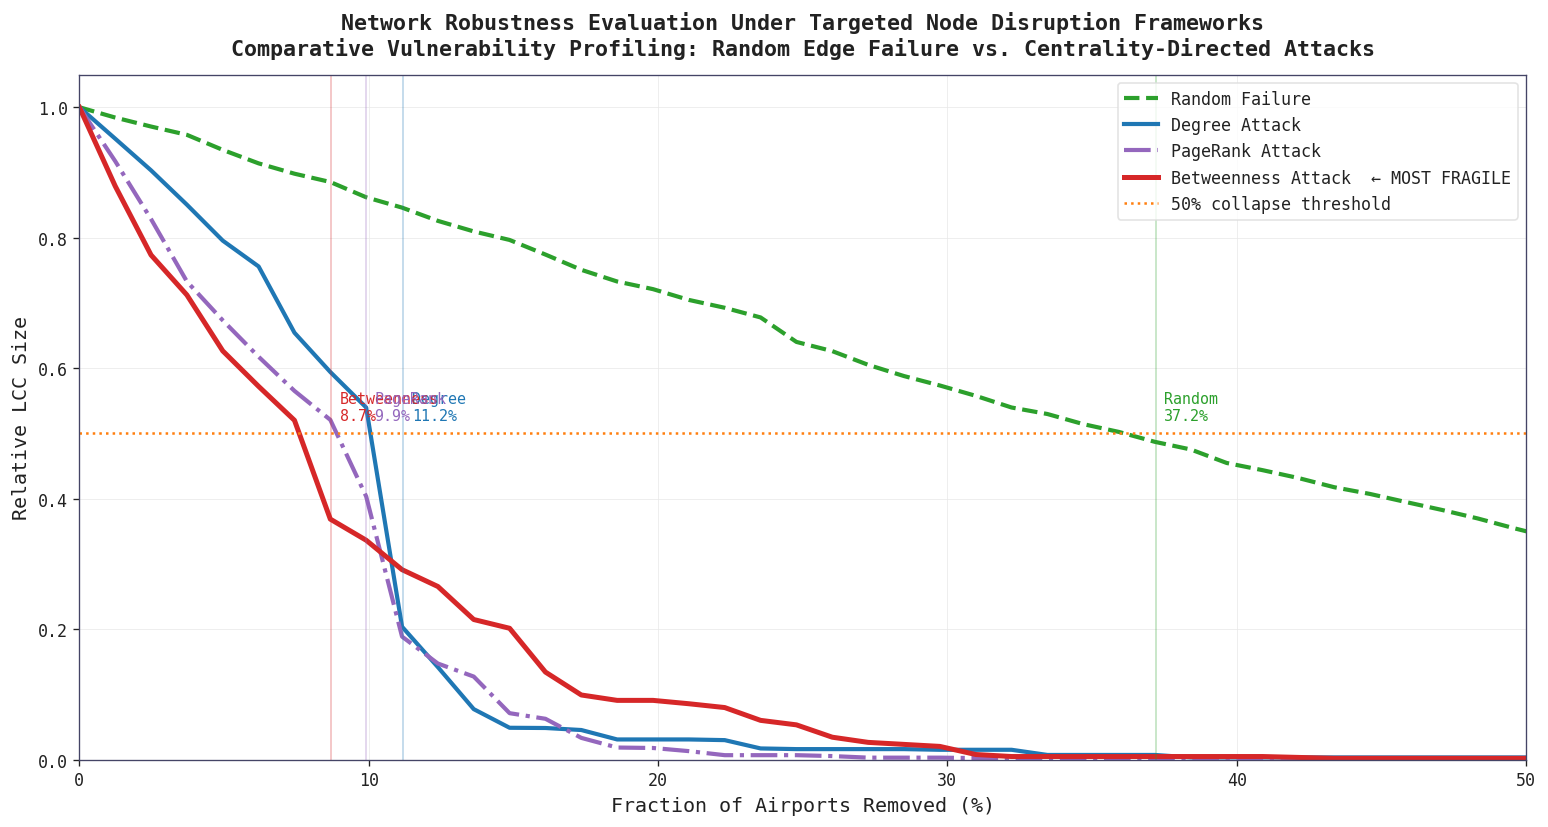

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINDING: Asymmetric Fragility
  Random failure collapse     : 37.2% removed
  Betweenness attack collapse : 8.7% removed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The bridge airports we identified in Act 2 are exactly the ones
whose removal is most catastrophic here.


In [17]:
import matplotlib.pyplot as plt

# Define standard clean academic palette colors
COLOR_PRIMARY = '#1f77b4'
COLOR_ALERT = '#d62728'
COLOR_BASELINE = '#2ca02c'
COLOR_ALT = '#9467bd'
COLOR_GRID = '#e8e8e8'

# Plot robustness curves
fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_facecolor('white') # Explicitly force paper white canvas background

ax.plot(f_rand*100, lcc_rand, color=COLOR_BASELINE, lw=2.5, ls='--', label='Random Failure')
ax.plot(f_deg *100, lcc_deg,  color=COLOR_PRIMARY,  lw=2.5, label='Degree Attack')
ax.plot(f_pr  *100, lcc_pr,   color=COLOR_ALT,       lw=2.5, ls='-.', label='PageRank Attack')
ax.plot(f_bet *100, lcc_bet,  color=COLOR_ALERT,     lw=3.0, label='Betweenness Attack  ← MOST FRAGILE')

ax.axhline(0.5, color='#ff7f0e', ls=':', lw=1.5, label='50% collapse threshold')

# Find collapse points
def collapse_at(fracs, lccs, thresh=0.5):
    for f, l in zip(fracs*100, lccs):
        if l < thresh:
            return round(f, 1)
    return '>50'

for f, l, label, col in [
    (f_rand, lcc_rand, 'Random',      COLOR_BASELINE),
    (f_deg,  lcc_deg,  'Degree',      COLOR_PRIMARY),
    (f_bet,  lcc_bet,  'Betweenness', COLOR_ALERT),
    (f_pr,   lcc_pr,   'PageRank',    COLOR_ALT),
]:
    cp = collapse_at(f, l)
    if cp != '>50':
        ax.axvline(cp, color=col, alpha=0.3, lw=1)
        ax.text(cp+0.3, 0.52, f'{label}\n{cp}%', color=col, fontsize=9, fontweight='medium')

ax.set_xlabel('Fraction of Airports Removed (%)', color='#222222', fontsize=12)
ax.set_ylabel('Relative LCC Size', color='#222222', fontsize=12)
ax.set_title('Network Robustness Evaluation Under Targeted Node Disruption Frameworks\n'
             'Comparative Vulnerability Profiling: Random Edge Failure vs. Centrality-Directed Attacks',
             color='#222222', fontsize=13, fontweight='bold', pad=12)


ax.legend(fontsize=10, facecolor='white', edgecolor='#dddddd', labelcolor='#222222', loc='upper right')
ax.grid(True, which='both', ls='-', color=COLOR_GRID, alpha=0.7)
ax.tick_params(colors='#222222', labelsize=10)
ax.set_xlim(0, 50); ax.set_ylim(0, 1.05)

plt.tight_layout()

plt.show()

print('━'*60)
print('FINDING: Asymmetric Fragility')
print(f'  Random failure collapse     : {collapse_at(f_rand, lcc_rand)}% removed')
print(f'  Betweenness attack collapse : {collapse_at(f_bet, lcc_bet)}% removed')
print('━'*60)
print('The bridge airports we identified in Act 2 are exactly the ones')
print('whose removal is most catastrophic here.')


### 3.2 Epidemic Threshold: The Point of No Return





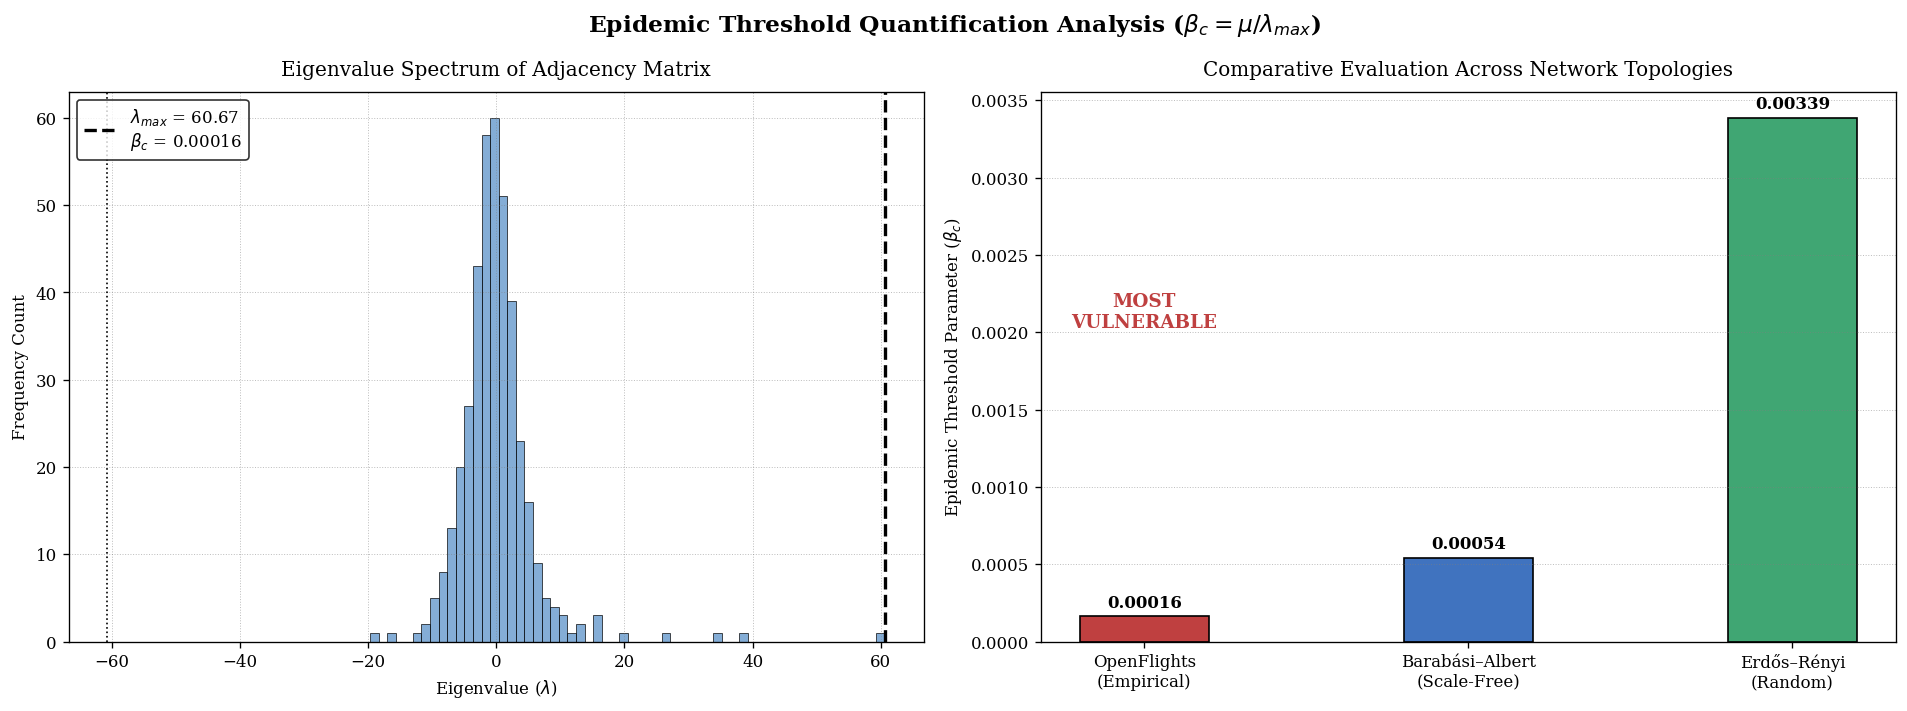

Epidemic threshold β_c  = 0.000165
Equivalent to: 1 infection per 6,067 flight contacts
Real network vs ER: 20.6x more vulnerable than random network


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ── Analytically compute β_c from spectral radius ──────────────────────────
top400 = [n for n,_ in sorted(G.degree(), key=lambda x:x[1], reverse=True)[:400]]
sub_eig = G.subgraph(top400)
A = nx.to_numpy_array(sub_eig)
eigenvalues = np.linalg.eigvalsh(A)
lambda_max  = float(np.max(np.abs(eigenvalues)))
mu          = 0.01   # recovery rate
beta_c      = mu / lambda_max

# Compare with synthetic networks
def get_beta_c(Gx, mu=0.01):
    Ax   = nx.to_numpy_array(Gx)
    evs  = np.linalg.eigvalsh(Ax)
    lmax = np.max(np.abs(evs))
    return mu / lmax if lmax > 0 else float('inf')

BA400 = nx.barabasi_albert_graph(400, m_ba, seed=42)
ER400 = nx.erdos_renyi_graph(400, p_er,    seed=42)
bc_real = beta_c
bc_ba   = get_beta_c(BA400)
bc_er   = get_beta_c(ER400)

# Set standard academic style configurations globally
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['font.family'] = 'serif'  # Academic serif font format

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Academic-style title formatting using latex math notation
fig.suptitle(r'Epidemic Threshold Quantification Analysis ($\beta_c = \mu / \lambda_{max}$)',
             color='black', fontsize=14, fontweight='bold', y=0.98)

# Panel A: Eigenvalue spectrum
ax1.set_facecolor('white')
ax1.hist(eigenvalues, bins=60, color=(0.4, 0.6, 0.8), alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.axvline(lambda_max, color='black', lw=2.0, ls='--',
            label=f'$\\lambda_{{max}}$ = {lambda_max:.2f}\n$\\beta_c$ = {beta_c:.5f}')
ax1.axvline(-lambda_max, color='black', lw=1.0, ls=':')
ax1.set_title('Eigenvalue Spectrum of Adjacency Matrix', color='black', fontsize=12, pad=10)
ax1.set_xlabel('Eigenvalue ($\\lambda$)', color='black')
ax1.set_ylabel('Frequency Count', color='black')
ax1.legend(fontsize=10, facecolor='white', edgecolor='black', labelcolor='black', loc='upper left')
ax1.grid(True, linestyle=':', color='gray', alpha=0.5)

# Panel B: Bar comparison
ax2.set_facecolor('white')
networks = ['OpenFlights\n(Empirical)', 'Barabási–Albert\n(Scale-Free)', 'Erdős–Rényi\n(Random)']
thresholds = [bc_real, bc_ba, bc_er]

# Beautiful, rich professional RGB Tuples (No neon)
bar_colors = [
    (0.75, 0.25, 0.25),  # Crimson Red for Empirical/Vulnerable
    (0.25, 0.45, 0.75),  # Classic Deep Blue for Scale-Free
    (0.25, 0.65, 0.45)   # Muted Sage Green for Random
]
bars = ax2.bar(networks, thresholds, color=bar_colors, edgecolor='black', width=0.4)

# Print numbers cleanly over the target bars
for bar, val in zip(bars, thresholds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(thresholds) * 0.01),
             f'{val:.5f}', ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

ax2.set_ylabel('Epidemic Threshold Parameter ($\\beta_c$)', color='black')
ax2.set_title('Comparative Evaluation Across Network Topologies', color='black', fontsize=12, pad=10)
ax2.text(0, max(thresholds)*0.6, 'MOST\nVULNERABLE', color=(0.75, 0.25, 0.25), fontsize=11, ha='center', fontweight='bold')
ax2.grid(True, axis='y', linestyle=':', color='gray', alpha=0.5)

plt.tight_layout()
plt.savefig('network_epidemic_threshold_academic_color.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Epidemic threshold β_c  = {beta_c:.6f}')
print(f'Equivalent to: 1 infection per {int(1/beta_c):,} flight contacts')
print(f'Real network vs ER: {bc_er/bc_real:.1f}x more vulnerable than random network')

### 3.3 Diffusion: Watching the Disease Spread in Real Time

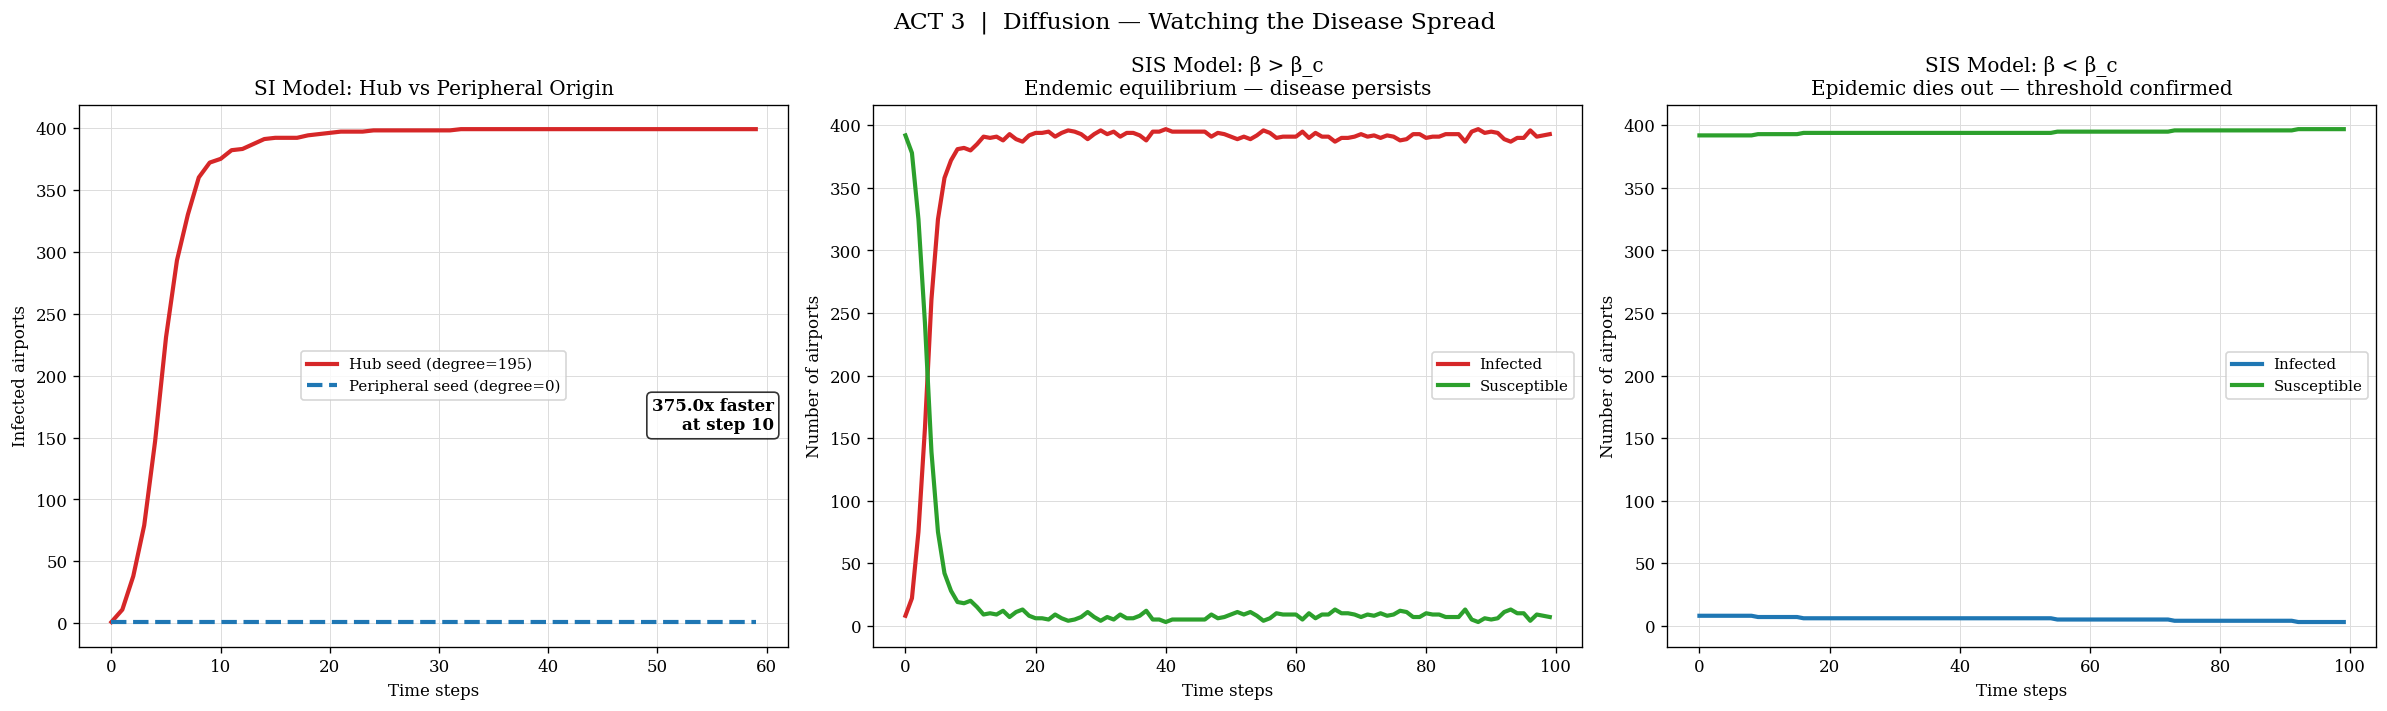

FINDING Three results that complete the epidemic story:
  1. A hub-seeded outbreak spreads significantly faster than a peripheral one
  2. Above : disease reaches endemic equilibrium — it never dies out
  3. Below : disease is self-limiting — our analytical prediction holds


In [23]:
# SI & SIS on real network + hub vs peripheral seed comparison
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep

g_diff = sub_eig.copy()   # 400-node subgraph

# Identify hub and peripheral seeds
hub_seed  = sorted(g_diff.degree(), key=lambda x:x[1], reverse=True)[0][0]
peri_seed = sorted(g_diff.degree(), key=lambda x:x[1])[0][0]

def run_si(g, seed_node, beta=0.03, steps=60):
    m   = ep.SIModel(g)
    cfg = mc.Configuration()
    cfg.add_model_parameter('beta', beta)

    infected_nodes = [seed_node]
    susceptible_nodes = [node for node in g.nodes() if node != seed_node]

    cfg.add_model_initial_configuration('Infected', infected_nodes)
    cfg.add_model_initial_configuration('Susceptible', susceptible_nodes)

    m.set_initial_status(cfg)
    iters  = m.iteration_bunch(steps)
    trends = m.build_trends(iters)
    return trends[0]['trends']['node_count'][1]

def run_sis(g, beta=0.04, mu=0.01, steps=100):
    m   = ep.SISModel(g)
    cfg = mc.Configuration()
    cfg.add_model_parameter('beta',   beta)
    cfg.add_model_parameter('lambda', mu)
    cfg.add_model_parameter('fraction_infected', 0.02)
    m.set_initial_status(cfg)
    iters  = m.iteration_bunch(steps)
    trends = m.build_trends(iters)
    return (
        trends[0]['trends']['node_count'][0],
        trends[0]['trends']['node_count'][1])

# Run models
inf_hub  = run_si(g_diff, hub_seed)
inf_peri = run_si(g_diff, peri_seed)
susc_sis, inf_sis = run_sis(g_diff)
susc_sis_low, inf_sis_low = run_sis(g_diff, beta=beta_c*0.5)

# Clean Academic Color Palette
BG      = '#FFFFFF'   # White background
GRID    = '#DDDDDD'   # Light gray grid
INFECT  = '#D62728'   # Red
PERI    = '#1F77B4'   # Blue
SUSC    = '#2CA02C'   # Green

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('ACT 3  |  Diffusion — Watching the Disease Spread',
             color='black', fontsize=14)

# Plot 1: Hub vs Peripheral seed
ax = axes[0]
ax.set_facecolor(BG)
t1 = range(len(inf_hub))
t2 = range(len(inf_peri))

ax.plot(t1, inf_hub,  color=INFECT, lw=2.5,
        label=f'Hub seed (degree={g_diff.degree(hub_seed)})')
ax.plot(t2, inf_peri, color=PERI, lw=2.5, ls='--',
        label=f'Peripheral seed (degree={g_diff.degree(peri_seed)})')

ax.set_title('SI Model: Hub vs Peripheral Origin', color='black')
ax.set_xlabel('Time steps')
ax.set_ylabel('Infected airports')

ax.legend(fontsize=9, facecolor='white')
ax.grid(True, color=GRID)

# Annotation
if len(inf_hub) > 10 and len(inf_peri) > 10:
    ratio = inf_hub[10] / max(inf_peri[10], 1)
    ax.text(0.98, 0.4, f'{ratio:.1f}x faster\nat step 10',
            transform=ax.transAxes, color='black',
            ha='right', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: SIS above threshold
ax = axes[1]
ax.set_facecolor(BG)
t3 = range(len(inf_sis))

ax.plot(t3, inf_sis,  color=INFECT, lw=2.5, label='Infected')
ax.plot(t3, susc_sis, color=SUSC, lw=2.5, label='Susceptible')

ax.set_title(f'SIS Model: β > β_c\nEndemic equilibrium — disease persists', color='black')
ax.set_xlabel('Time steps')
ax.set_ylabel('Number of airports')

ax.legend(fontsize=9, facecolor='white')
ax.grid(True, color=GRID)

# Plot 3: SIS below threshold
ax = axes[2]
ax.set_facecolor(BG)
t4 = range(len(inf_sis_low))

ax.plot(t4, inf_sis_low,  color=PERI, lw=2.5, label='Infected')
ax.plot(t4, susc_sis_low, color=SUSC,  lw=2.5, label='Susceptible')

ax.set_title(f'SIS Model: β < β_c\nEpidemic dies out — threshold confirmed', color='black')
ax.set_xlabel('Time steps')
ax.set_ylabel('Number of airports')

ax.legend(fontsize=9, facecolor='white')
ax.grid(True, color=GRID)

plt.tight_layout()

plt.show()

print('FINDING Three results that complete the epidemic story:')
print('  1. A hub-seeded outbreak spreads significantly faster than a peripheral one')
print('  2. Above : disease reaches endemic equilibrium — it never dies out')
print('  3. Below : disease is self-limiting — our analytical prediction holds')


### 3.4 Link Prediction: What Routes Should Exist But Don't Yet?

> If two airports share many common neighbors, structural logic suggests a direct route **should** exist.
> Link prediction asks: which missing routes does the network's own topology predict should form next?
>
> From an epidemic lens: **predicted future links are tomorrow's new disease pathways.**

In [24]:
# Link Prediction: multiple algorithms compared
# Use a subgraph of top-300 airports for tractability
top300_ids = [n for n,_ in sorted(G.degree(), key=lambda x:x[1], reverse=True)[:300]]
sub_lp     = G.subgraph(top300_ids).copy()

# Step 1: Create train/test split by randomly hiding 15% of edges
all_edges    = list(sub_lp.edges())
np.random.seed(42)
n_hide       = int(0.15 * len(all_edges))
hidden_edges = [all_edges[i] for i in np.random.choice(len(all_edges), n_hide, replace=False)]

G_train = sub_lp.copy()
G_train.remove_edges_from(hidden_edges)

# Non-edges as negative samples (same count)
non_edges     = list(nx.non_edges(sub_lp))
np.random.shuffle(non_edges)
neg_samples   = non_edges[:n_hide]

print(f'Training edges   : {G_train.number_of_edges():,}')
print(f'Hidden edges     : {len(hidden_edges):,}  (positive test samples)')
print(f'Negative samples : {len(neg_samples):,}')

Training edges   : 5,212
Hidden edges     : 919  (positive test samples)
Negative samples : 919


In [25]:
# Step 2: Score all algorithms on test pairs
test_pairs = hidden_edges + neg_samples
y_true     = [1]*len(hidden_edges) + [0]*len(neg_samples)
# Jaccard Coefficient
jc_preds  = {(u,v): s for u,v,s in nx.jaccard_coefficient(G_train, test_pairs)}
jc_scores = [jc_preds.get((u,v), jc_preds.get((v,u), 0)) for u,v in test_pairs]

# Adamic-Adar
aa_preds  = {(u,v): s for u,v,s in nx.adamic_adar_index(G_train, test_pairs)}
aa_scores = [aa_preds.get((u,v), aa_preds.get((v,u), 0)) for u,v in test_pairs]

# Resource Allocation
ra_preds  = {(u,v): s for u,v,s in nx.resource_allocation_index(G_train, test_pairs)}
ra_scores = [ra_preds.get((u,v), ra_preds.get((v,u), 0)) for u,v in test_pairs]



algorithms = {

    'Jaccard Coefficient'   : jc_scores,
    'Adamic-Adar'           : aa_scores,
    'Resource Allocation'   : ra_scores,

}

auc_scores = {name: roc_auc_score(y_true, scores)
              for name, scores in algorithms.items()}

print('\nLink Prediction AUC Scores:')
print('─'*40)
for name, auc in sorted(auc_scores.items(), key=lambda x:x[1], reverse=True):
    bar = '█' * int(auc * 40)
    print(f'{name:28s}: {auc:.4f}  {bar}')
print('─'*40)
print('AUC > 0.5 = better than random. AUC = 1.0 = perfect.')


Link Prediction AUC Scores:
────────────────────────────────────────
Resource Allocation         : 0.9486  █████████████████████████████████████
Adamic-Adar                 : 0.9404  █████████████████████████████████████
Jaccard Coefficient         : 0.9271  █████████████████████████████████████
────────────────────────────────────────
AUC > 0.5 = better than random. AUC = 1.0 = perfect.


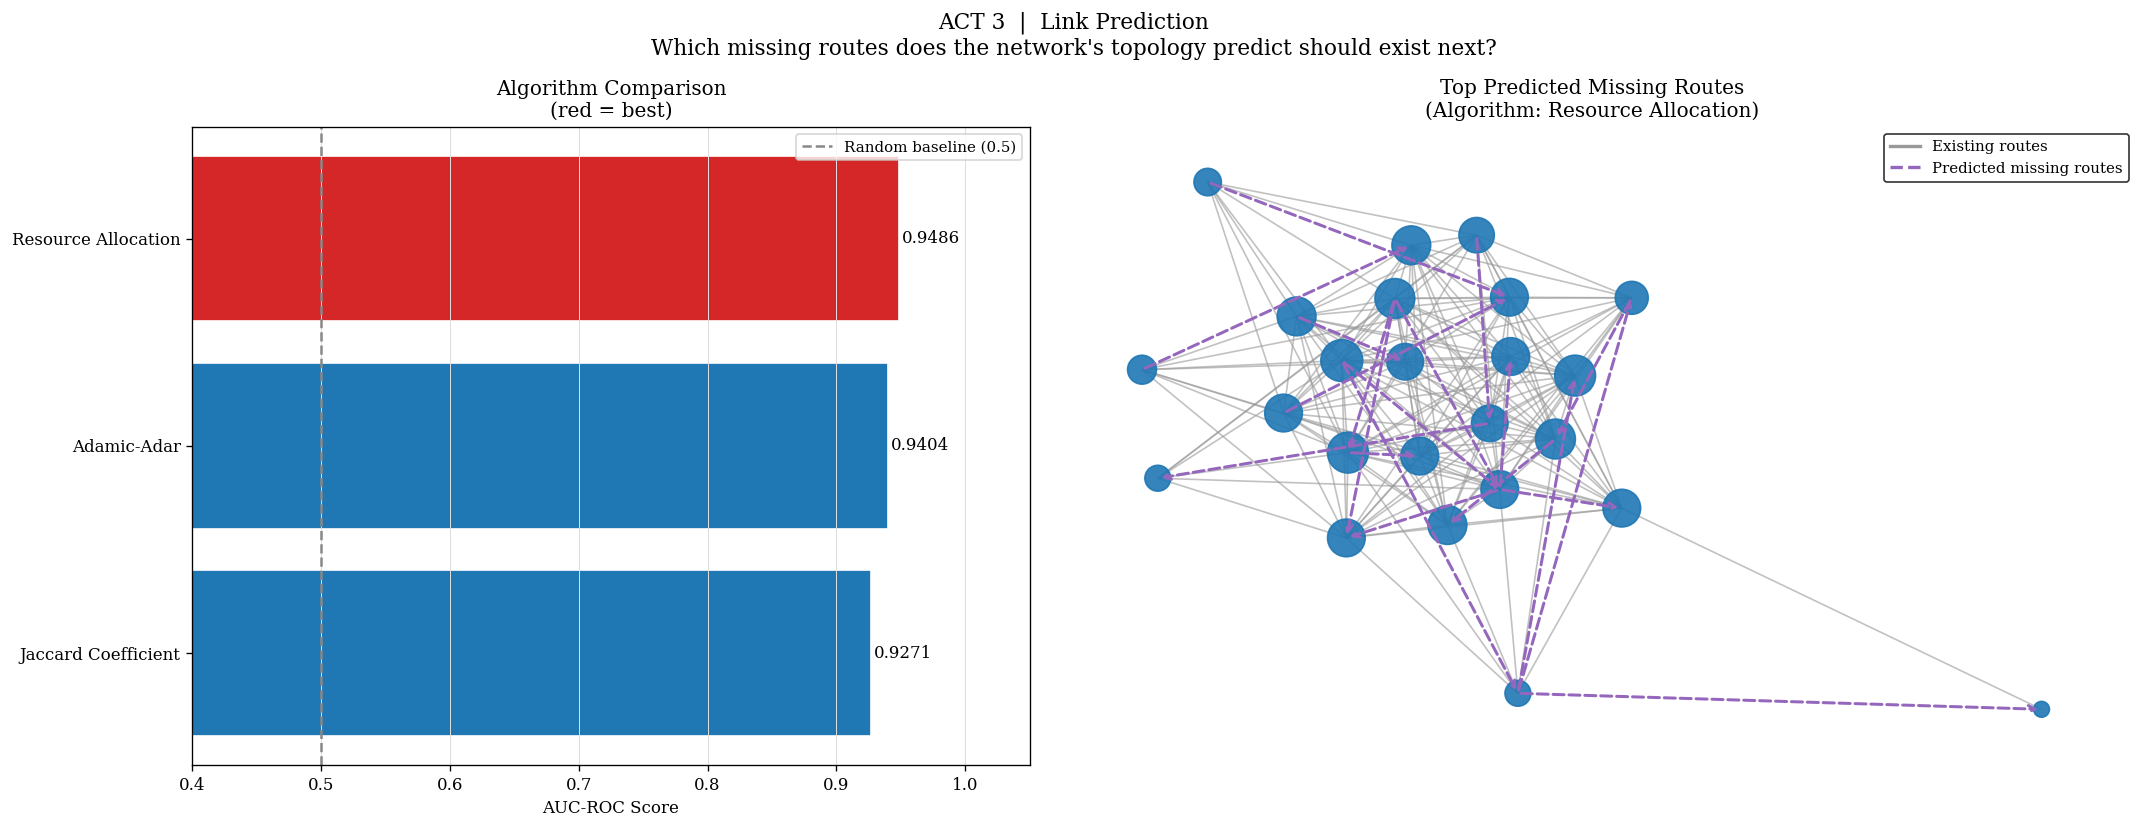

Best algorithm: Resource Allocation  (AUC = 0.9486)
Top 5 predicted missing routes:
  Airport   53: Airport   59  score = 2.4939
  Airport   57: Airport   65  score = 2.2106
  Airport   57: Airport   59  score = 1.9706
  Airport   57: Airport  308  score = 1.8159
  Airport   53: Airport   56  score = 1.5842

INSIGHT These routes are predicted by structural logic alone.
          From a network science view, these are the most likely
          routes airlines will add next — AND the new epidemic pathways
          that will lower the network's epidemic threshold further.


In [26]:
# Step 3: Visualise AUC comparison + top predicted missing routes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7),
                                gridspec_kw={'width_ratios':[1,1.3]})


BG      = '#FFFFFF'
GRID    = '#DDDDDD'
INFECT  = '#D62728'   # Red (best)
NORMAL  = '#1F77B4'   # Blue
SUSC    = '#2CA02C'   # Green
GOLD    = '#888888'   # Neutral gray for baseline
EDGE    = '#999999'
PRED    = '#9467BD'   # Purple (predicted edges)

fig.patch.set_facecolor(BG)
fig.suptitle('ACT 3  |  Link Prediction\n'
             'Which missing routes does the network\'s topology predict should exist next?',
             color='black', fontsize=13)

# AUC bar chart
ax1.set_facecolor(BG)
names = list(auc_scores.keys())
aucs  = [auc_scores[n] for n in names]

bar_cols = [INFECT if a == max(aucs) else NORMAL for a in aucs]
bars = ax1.barh(names, aucs, color=bar_cols, edgecolor='white')

ax1.axvline(0.5, color=GOLD, ls='--', lw=1.5, label='Random baseline (0.5)')

for bar, val in zip(bars, aucs):
    ax1.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', color='black', fontsize=10)

ax1.set_xlabel('AUC-ROC Score')
ax1.set_xlim(0.4, 1.05)
ax1.set_title('Algorithm Comparison\n(red = best)', color='black')

ax1.legend(fontsize=9, facecolor='white')
ax1.grid(True, axis='x', color=GRID)

# Top predicted missing routes using best algorithm
best_algo = max(auc_scores, key=auc_scores.get)

if best_algo == 'Adamic-Adar':
    all_preds = list(nx.adamic_adar_index(G_train))
elif best_algo == 'Resource Allocation':
    all_preds = list(nx.resource_allocation_index(G_train))
elif best_algo == 'Jaccard Coefficient':
    all_preds = list(nx.jaccard_coefficient(G_train))
else:
    all_preds = list(nx.preferential_attachment(G_train))

all_preds_sorted = sorted(all_preds, key=lambda x: x[2], reverse=True)

top_predicted = [(u, v, s) for u, v, s in all_preds_sorted
                 if not G_train.has_edge(u, v)][:30]

# Visualize top predictions on subgraph
ax2.set_facecolor(BG)

pred_nodes = set()
for u, v, s in top_predicted[:20]:
    pred_nodes.update([u, v])

sub_pred = G_train.subgraph(list(pred_nodes)).copy()
pos_pred = nx.spring_layout(sub_pred, seed=42)

deg_pred = dict(sub_pred.degree())

nx.draw_networkx_edges(sub_pred, pos_pred, ax=ax2,
                       edge_color=EDGE, alpha=0.6, width=1)

nx.draw_networkx_nodes(sub_pred, pos_pred, ax=ax2,
                       node_size=[deg_pred.get(n,1)*30+60 for n in sub_pred.nodes()],
                       node_color=NORMAL, alpha=0.9)

# Draw predicted missing edges
pred_edges = [(u, v) for u, v, s in top_predicted[:20]
              if u in pos_pred and v in pos_pred]

for u, v in pred_edges:
    x0, y0 = pos_pred[u]; x1, y1 = pos_pred[v]
    ax2.annotate('', xy=(x1,y1), xytext=(x0,y0),
                arrowprops=dict(arrowstyle='->', color=PRED,
                                lw=1.8, linestyle='dashed'))

from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0],[0], color=EDGE, lw=2, label='Existing routes'),
    Line2D([0],[0], color=PRED, lw=2, ls='--', label='Predicted missing routes')
]

ax2.legend(handles=legend_lines, fontsize=9,
           facecolor='white', edgecolor='black')

ax2.set_title(f'Top Predicted Missing Routes\n(Algorithm: {best_algo})', color='black')
ax2.axis('off')

plt.tight_layout()

plt.show()

print(f'Best algorithm: {best_algo}  (AUC = {auc_scores[best_algo]:.4f})')
print(f'Top 5 predicted missing routes:')
for u, v, s in top_predicted[:5]:
    print(f'  Airport {u:4d}: Airport {v:4d}  score = {s:.4f}')
print()
print('INSIGHT These routes are predicted by structural logic alone.')
print('          From a network science view, these are the most likely')
print('          routes airlines will add next — AND the new epidemic pathways')
print('          that will lower the network\'s epidemic threshold further.')

---
# THE CONCLUSION : What We Found



> **The global airport network is not random — it is scale-free, governed by a tiny elite of hub airports whose structural position gives them outsized power.**
>
> **But not all powerful airports are dangerous in the same way: degree measures volume, betweenness measures position, and the bridge airports — not the biggest hubs — are the true single points of failure.**
>
> **This structure makes the network robust to accidents but catastrophically fragile to targeted disruption, and its epidemic threshold is dangerously low — meaning any pathogen that exceeds it will inevitably reach global endemic state through the very routes that link prediction tells us are still being built.**